In [ ]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import math

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness, BatchNormalization, GlobalAveragePooling2D

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ["rock","peace", "ok", "one",'dislike','like','stop','fist','three','two_up']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

PATH = "gesture_dataset_sample"

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [ ]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [3]:
# pretty-print first element
#print(json.dumps(annotations['like']['004b66dd-19e0-47cd-968e-c1b56f9e9179'], indent=2))

## helper function to pre-process images (color channel conversion and resizing)

In [4]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [ ]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f"{PATH}/{condition}")):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

X = np.array(images)
y = np.array(labels)

  0%|          | 0/251 [00:00<?, ?it/s]

''


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/251 [00:00<?, ?it/s]

''


...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/251 [00:00<?, ?it/s]

''


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

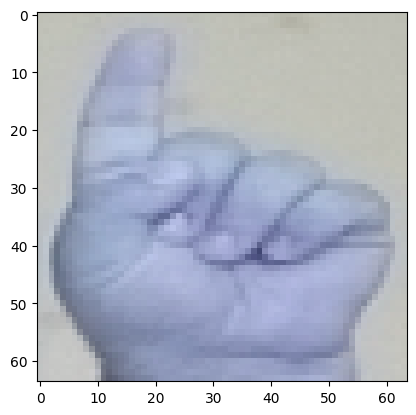

In [6]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2000
500
2000
500


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [8]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(2000, 64, 64, 3) (500, 64, 64, 3) (2000, 10) (500, 10)


In [ ]:
# variables for hyperparameters
batch_size = 32
epochs = 200
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()
model.add(Input(shape=(SIZE[0], SIZE[1], COLOR_CHANNELS))) #kept getting a Warning Message, so added input like this
# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.05))
model.add(RandomRotation(0.1))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(32, (3,3), padding='same', activation=activation_conv))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), padding='same', activation=activation_conv))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), padding='same', activation=activation_conv))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), padding='same', activation=activation_conv))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())
model.add(Dense(128, activation=activation))
model.add(BatchNormalization())

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.3))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

## now, we can train the model using the fit() function
## this will take a while

In [18]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.2775 - loss: 2.3673 - val_accuracy: 0.1460 - val_loss: 2.5388 - learning_rate: 0.0010
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.4870 - loss: 1.5177 - val_accuracy: 0.1600 - val_loss: 2.2639 - learning_rate: 0.0010
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6275 - loss: 1.0672 - val_accuracy: 0.2480 - val_loss: 2.0561 - learning_rate: 0.0010
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7020 - loss: 0.8751 - val_accuracy: 0.5000 - val_loss: 1.5398 - learning_rate: 0.0010
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7600 - loss: 0.6902 - val_accuracy: 0.5600 - val_loss: 1.3339 - learning_rate: 0.0010
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.7915 - loss: 0.6221 - val_accuracy: 0.5040 - val_loss: 1.3303 - learning_rate: 0.0010
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8325 - loss: 0.5002 - 

In [147]:
# let's have a look at our model
model.summary()

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_35 (RandomFlip)          │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast_38 (RandomContrast)  │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_109 (Conv2D)                  │ (None, 64, 64, 64)          │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_64               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_110 (Conv2D)                  │ (None, 64, 64, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_111 (Conv2D)                  │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_65               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_112 (Conv2D)                  │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_65 (MaxPooling2D)      │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_18 (Flatten)                 │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_132 (Dense)                    │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_133 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_134 (Dense)                    │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,712,558 (6.53 MB)

 Trainable params: 570,788 (2.18 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 1,141,578 (4.35 MB)

## Plot accuracy and loss of the training process

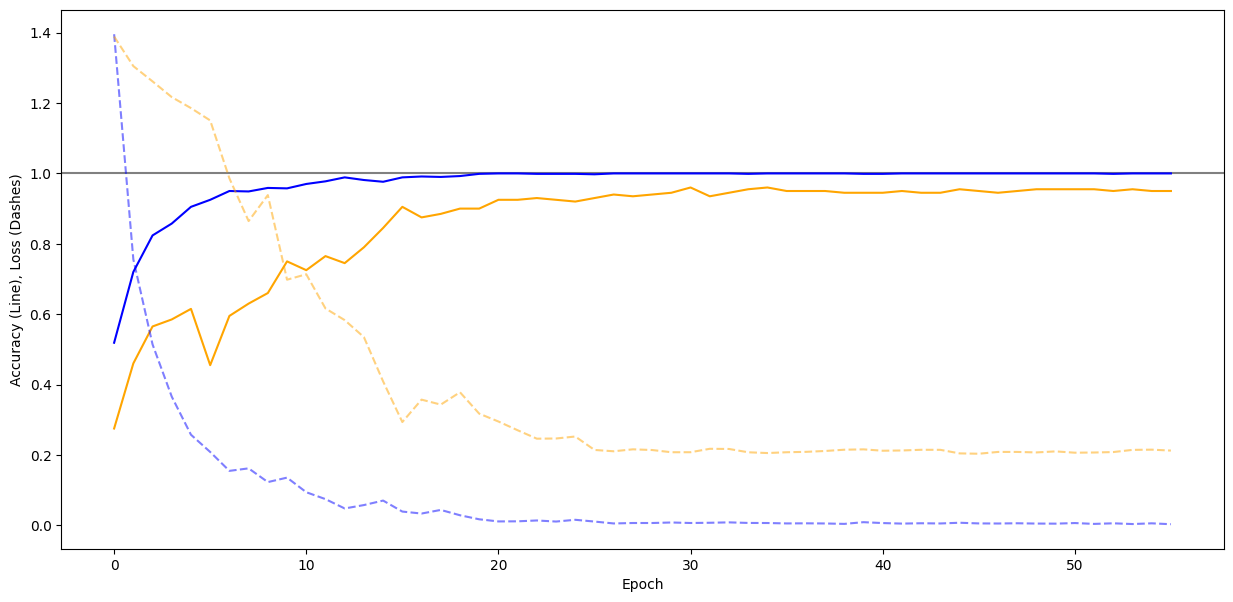

In [82]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## saving the model

the function will create a directory for your model and save structure and weights in there

sometimes you will see the .h5 format being used - even though this is a bit faster and needs less space, it comes with its limitations and isn't used that much any more

In [ ]:
if not os.path.exists("models/for-camera-app"):
    os.makedirs("models/for-camera-app")
model.save(f'models/for-camera-app/gesture_recognition_{IMG_SIZE}_{CONDITIONS}_9500_with rotation.keras')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition")

## visualize classification results with a confusion matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
before [[5.80518897e-11 7.83751716e-07 9.99999166e-01 4.56991209e-08]
 [7.46366857e-11 6.97102369e-05 9.99930263e-01 2.81177095e-11]
 [2.15507028e-13 1.98491601e-09 1.00000000e+00 8.24130781e-12]
 [1.96170788e-07 1.52152235e-04 9.99846935e-01 6.26066594e-07]
 [5.57998869e-10 9.99978304e-01 1.30052786e-05 8.67774634e-06]
 [5.17129549e-04 2.19683219e-02 9.76839483e-01 6.75060612e-04]
 [1.00422405e-15 1.16278223e-08 9.99999881e-01 1.01735708e-07]
 [4.21241514e-10 5.26977203e-07 9.99999523e-01 5.60345326e-10]
 [2.45615465e-05 8.84442031e-02 1.50871673e-03 9.10022438e-01]
 [9.99995828e-01 2.64230493e-06 3.60365306e-07 1.21147059e-06]
 [2.07991285e-12 3.93292521e-06 9.44353129e-09 9.99996066e-01]
 [9.99999881e-01 1.41588202e-07 2.37203928e-08 2.00321892e-08]
 [7.76352114e-14 1.04194245e-04 9.99895811e-01 2.60172751e-11]
 [1.06991536e-08 1.64966064e-03 2.20211950e-06 9.98348117e-01]
 [1.21564727e-12 2.85482267e-04 2.83868973e-09 9.99714553e-01]
 [1.866630

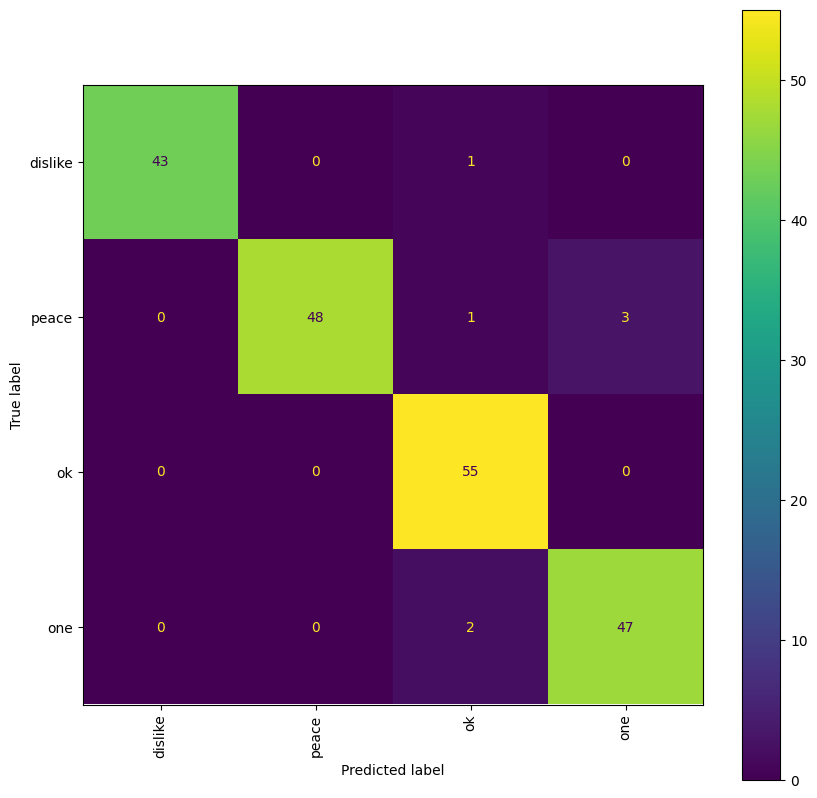

In [149]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
#print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

#print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## Transfer Learning

let's use a pre-trained model (VGG16) for our prediction

note that VGG16 needs three color channels

In [ ]:
batch_size = 32
epochs = 100
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 3
num_neurons = 256

# load a VGG16 model trained on the imagenet dataset
# include_top=False -> do not include the output layer
# input_tensor -> tells the model about the dimensions of our images (VGG16 needs three color channels)
# pooling -> which type of pooling to use between convolutions; max or avg seem to be the best
VGG = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3)), pooling='avg')

for layer in VGG.layers:
    layer.trainable = False

model_vgg = Sequential()
model_vgg.add(VGG)

model_vgg.add(Dense(num_neurons, activation=activation))
model_vgg.add(BatchNormalization()) 
model_vgg.add(Dropout(0.4))        

model_vgg.add(Dense(128, activation=activation))
model_vgg.add(BatchNormalization())
model_vgg.add(Dropout(0.3))         

model_vgg.add(Dense(num_classes, activation='softmax'))

model_vgg.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [93]:
history_vgg = model_vgg.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)
print("Finished")

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5038 - loss: 1.3364 - val_accuracy: 0.4250 - val_loss: 1.2246 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6837 - loss: 0.8205 - val_accuracy: 0.6150 - val_loss: 1.0984 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7625 - loss: 0.6096 - val_accuracy: 0.7350 - val_loss: 0.9941 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7725 - loss: 0.6226 - val_accuracy: 0.7700 - val_loss: 0.9232 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7975 - loss: 0.4923 - val_accuracy: 0.8000 - val_loss: 0.8477 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8213 - loss: 0.4742 - val_accuracy: 0.7950 - val_loss: 0.7837 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8388 - loss: 0.4409 - val_acc

In [ ]:
#Suggestion from ChatGPT, but didn't end up using transfered leraning anyway
for layer in base_model.layers:
    if layer.name.startswith('block5_conv'):
        layer.trainable = True
    else:
        layer.trainable = False

model_vgg.compile(
    loss='categorical_crossentropy', 
    optimizer="adam", 
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)
print("Finished")

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - accuracy: 0.9038 - loss: 0.2656 - val_accuracy: 0.7900 - val_loss: 0.5218 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step - accuracy: 0.9438 - loss: 0.1667 - val_accuracy: 0.8150 - val_loss: 0.4913 - learning_rate: 1.0000e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.9550 - loss: 0.1372 - val_accuracy: 0.8250 - val_loss: 0.4788 - learning_rate: 1.0000e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 322ms/step - accuracy: 0.9725 - loss: 0.0926 - val_accuracy: 0.8350 - val_loss: 0.4627 - learning_rate: 1.0000e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step - accuracy: 0.9737 - loss: 0.0944 - val_accuracy: 0.8300 - val_loss: 0.4208 - learning_rate: 1.0000e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.9787 - loss: 0.0785 - val_accuracy: 0.8350 - val_loss: 0.4175 - learning_rate: 1.0000e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - ac

In [152]:
model_vgg.summary()

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_33 (RandomFlip)          │ (32, 64, 64, 3)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_29 (RandomRotation)  │ (32, 64, 64, 3)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast_36 (RandomContrast)  │ (32, 64, 64, 3)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (32, 512)                   │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_125 (Dense)                    │ (32, 256)                   │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_126 (Dense)                    │ (32, 256)                   │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_127 (Dense)                    │ (32, 256)                   │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (32, 4)                     │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,506,510 (59.15 MB)

 Trainable params: 263,940 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 527,882 (2.01 MB)

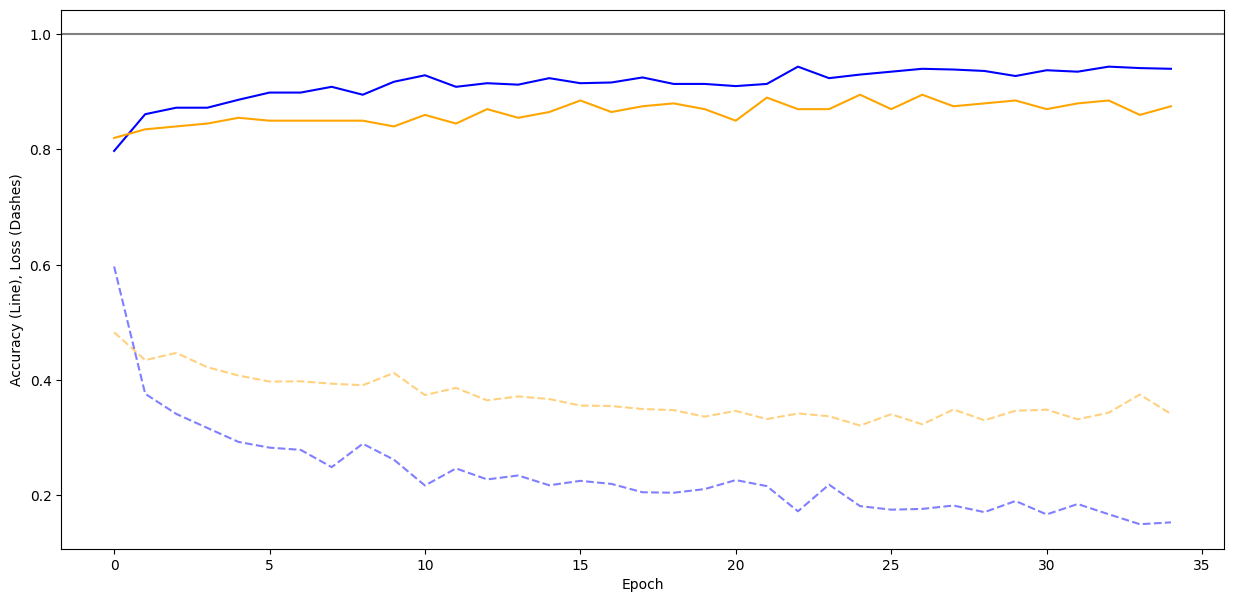

In [153]:
loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']
accuracy = history_vgg.history['accuracy']
val_accuracy = history_vgg.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
probabilities [2 2 2 2 1 2 2 2 0 0 3 0 2 3 3 3 3 3 3 1 2 0 1 2 0 0 0 1 3 3 1 0 2 3 1 0 1
 2 3 0 1 0 1 2 1 1 3 2 1 3 2 3 3 2 0 0 2 0 0 3 1 0 3 1 2 2 2 3 0 2 0 1 2 2
 1 1 2 0 2 1 2 0 1 0 1 2 3 2 3 1 1 1 2 0 1 1 3 0 0 3 2 3 3 1 2 2 2 3 0 3 2
 3 3 1 0 1 0 3 2 1 3 1 2 3 0 2 2 1 3 3 2 3 2 3 2 0 0 0 0 0 0 2 2 1 3 3 2 0
 3 1 2 0 3 1 3 1 1 0 0 2 2 3 2 2 3 2 1 2 1 1 1 1 0 3 2 1 1 2 3 2 1 2 1 2 3
 0 1 1 1 2 3 3 2 0 0 1 1 0 2 0]


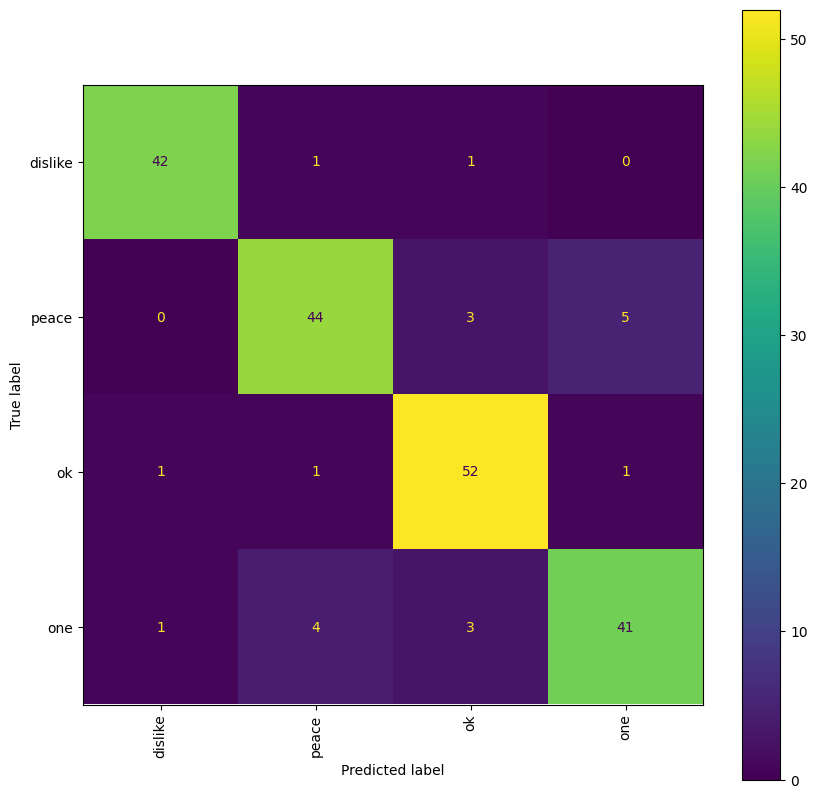

In [154]:
# let the model make predictions for our training data
y_predictions = model_vgg.predict(X_test)

# we get a 2D numpy array with probabilities for each category
#print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

In [ ]:
if not os.path.exists("models/for-camera-app"):
    os.makedirs("models/for-camera-app")
model_vgg.save(f'models/for-camera-app/transferLearning_gesture_recognition_{IMG_SIZE}.keras')